# Data science HW1
## Dr.Salavati
## Aria mokhtari varnousfaderani
ariamokhtarimain@gmail.com
Telegram : @randie
Bale : @ezzioaditore

In [16]:
!pip install -r requirements.txt

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
import warnings
 
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})
RANDOM_SEED = 42

In [18]:
print("=" * 60)
print("1. LOADING DATA")
print("=" * 60)
 
df = pd.read_csv("data/netflix_titles.csv")
print(f"Shape: {df.shape}")
print(df.head(3).to_string())

1. LOADING DATA
Shape: (8807, 12)
  show_id     type                 title         director                                                                                                                                                                                                                                                                                                             cast        country          date_added  release_year rating   duration                                                      listed_in                                                                                                                                               description
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson                                                                                                                                                                                                                                                                      

In [19]:
print("\n" + "=" * 60)
print("2. EXPLORATORY DATA ANALYSIS")
print("=" * 60)
 
df.info()
print("\nNumeric summary:")
print(df.describe().to_string())
 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Pct%": missing_pct})
missing_df = missing_df[missing_df["Missing"] > 0].sort_values("Pct%", ascending=False)
print("\nMissing values:")
print(missing_df.to_string())
 
for col in ["type", "rating"]:
    print(f"\n--- {col} value counts ---")
    print(df[col].value_counts().head(10).to_string())
 
print(f"\nRelease year range: {df['release_year'].min()} – {df['release_year'].max()}")
print(f"Content released 2019+: {(df['release_year'] >= 2019).sum()}")


2. EXPLORATORY DATA ANALYSIS
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB

Numeric summary:
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000

Missing values:
            Missing   Pct%
director 

In [20]:
print("\n" + "=" * 60)
print("3. DATA CLEANING")
print("=" * 60)
 
# Duplicates
dupes = df.duplicated(subset="show_id").sum()
print(f"Duplicate show_ids removed: {dupes}")
df.drop_duplicates(subset="show_id", inplace=True)
 
# Fill missing categoricals
for col in ["director", "cast", "country"]:
    df[col].fillna("Unknown", inplace=True)
 
# Rating: fill with mode
df["rating"].fillna(df["rating"].mode()[0], inplace=True)
 
# date_added: parse then fill missing with median
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(), format="%B %d, %Y", errors="coerce"
)
df["date_added"].fillna(df["date_added"].median(), inplace=True)
 
# duration → numeric value + unit
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)")
df.loc[df["duration"].isnull() & (df["type"] == "Movie"), "duration_unit"] = "min"
df.loc[df["duration"].isnull() & (df["type"] == "TV Show"), "duration_unit"] = "Season"
df["duration_value"].fillna(
    df.groupby("type")["duration_value"].transform("median"), inplace=True
)
 
# Remove logically invalid release years
df = df[(df["release_year"] >= 1900) & (df["release_year"] <= 2025)].copy()
 
print(f"Clean dataset shape: {df.shape}")
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls):
    print("Remaining nulls:", remaining_nulls.to_dict())
else:
    print("No remaining nulls in key columns.")



3. DATA CLEANING
Duplicate show_ids removed: 0
Clean dataset shape: (8807, 14)
Remaining nulls: {'director': 2634, 'cast': 825, 'country': 831, 'date_added': 10, 'rating': 4, 'duration': 3, 'duration_value': 3}


In [21]:
print("\n" + "=" * 60)
print("4. PREPROCESSING — ENCODING & NORMALIZATION")
print("=" * 60)
 
le = LabelEncoder()
for col in ["type", "rating"]:
    df[f"{col}_enc"] = le.fit_transform(df[col].astype(str))
 
num_features = ["release_year", "duration_value", "type_enc", "rating_enc"]
scaler = StandardScaler()
scaled_arr = scaler.fit_transform(df[num_features])
df_scaled = pd.DataFrame(
    scaled_arr,
    columns=[f"{c}_scaled" for c in num_features],
    index=df.index,
)
df = pd.concat([df, df_scaled], axis=1)
print("Scaled columns added:")
print(df[[f"{c}_scaled" for c in num_features]].describe().round(2).to_string())
 


4. PREPROCESSING — ENCODING & NORMALIZATION
Scaled columns added:
       release_year_scaled  duration_value_scaled  type_enc_scaled  rating_enc_scaled
count              8807.00                8804.00          8807.00            8807.00
mean                  0.00                   0.00             0.00               0.00
std                   1.00                   1.00             1.00               1.00
min                 -10.11                  -1.35            -0.66              -5.10
25%                  -0.13                  -1.34            -0.66              -0.52
50%                   0.32                   0.36            -0.66               0.50
75%                   0.55                   0.71             1.51               0.50
max                   0.77                   4.77             1.51               3.56



5. VISUALIZATIONS (matplotlib/seaborn + plotly)


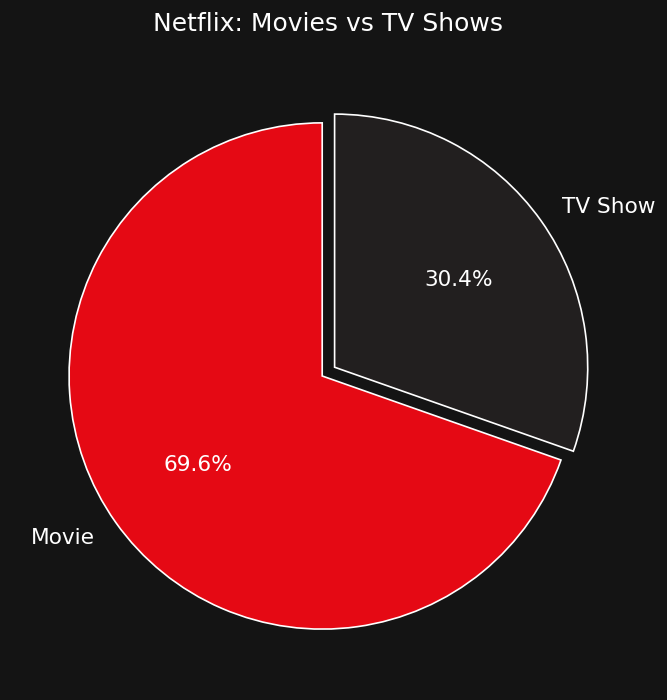

  → saved plot_01_pie.png


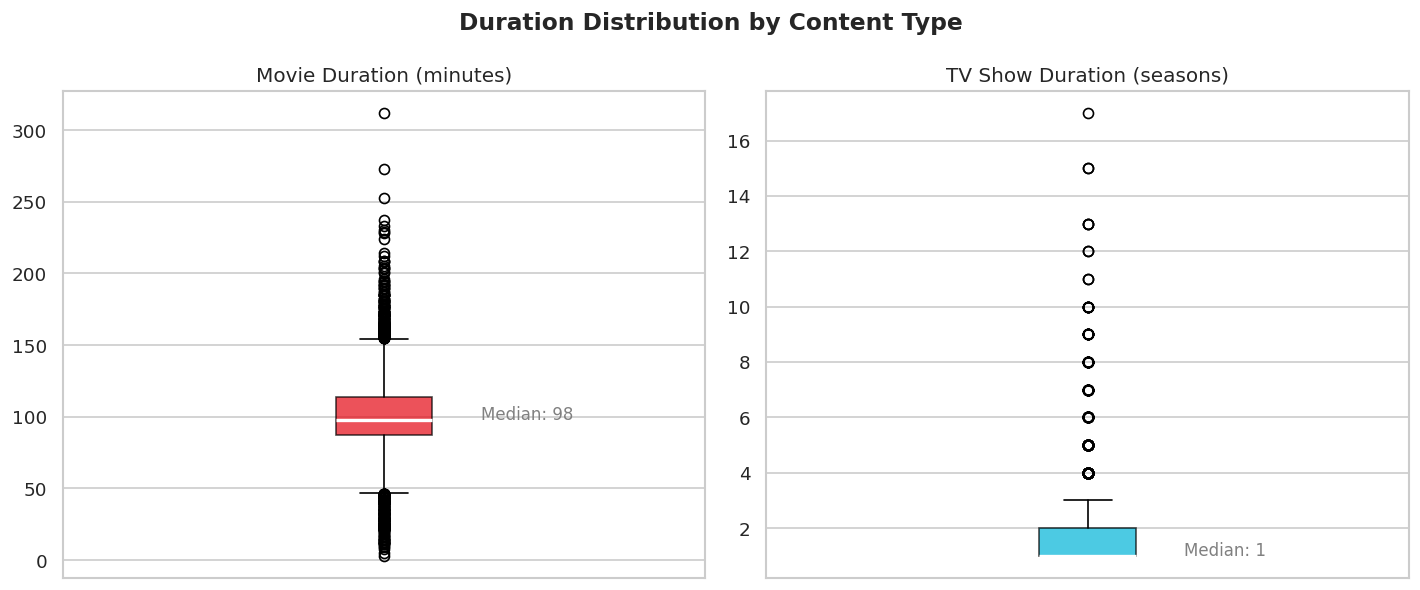

  → saved plot_02_boxplot.png


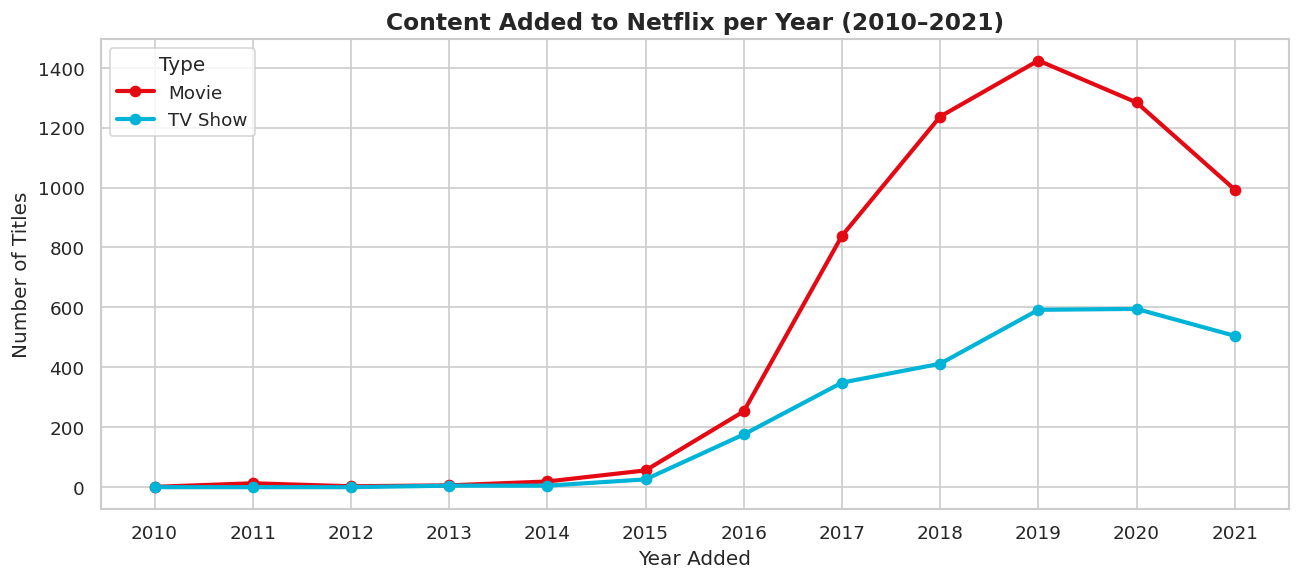

  → saved plot_03_line.png


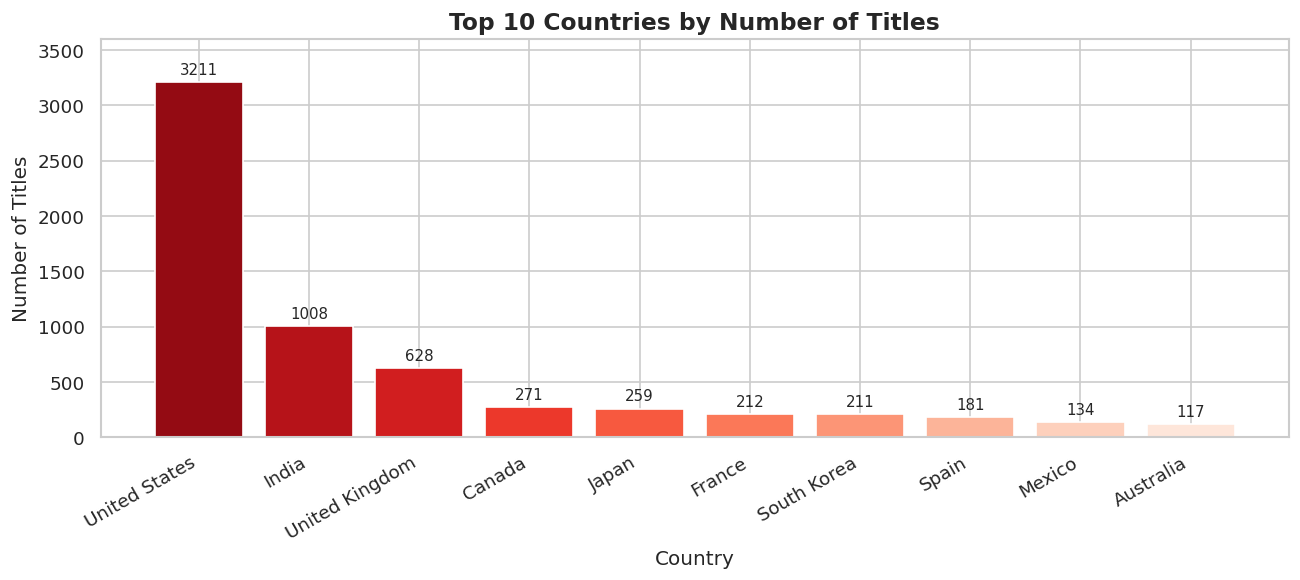

  → saved plot_04_bar.png


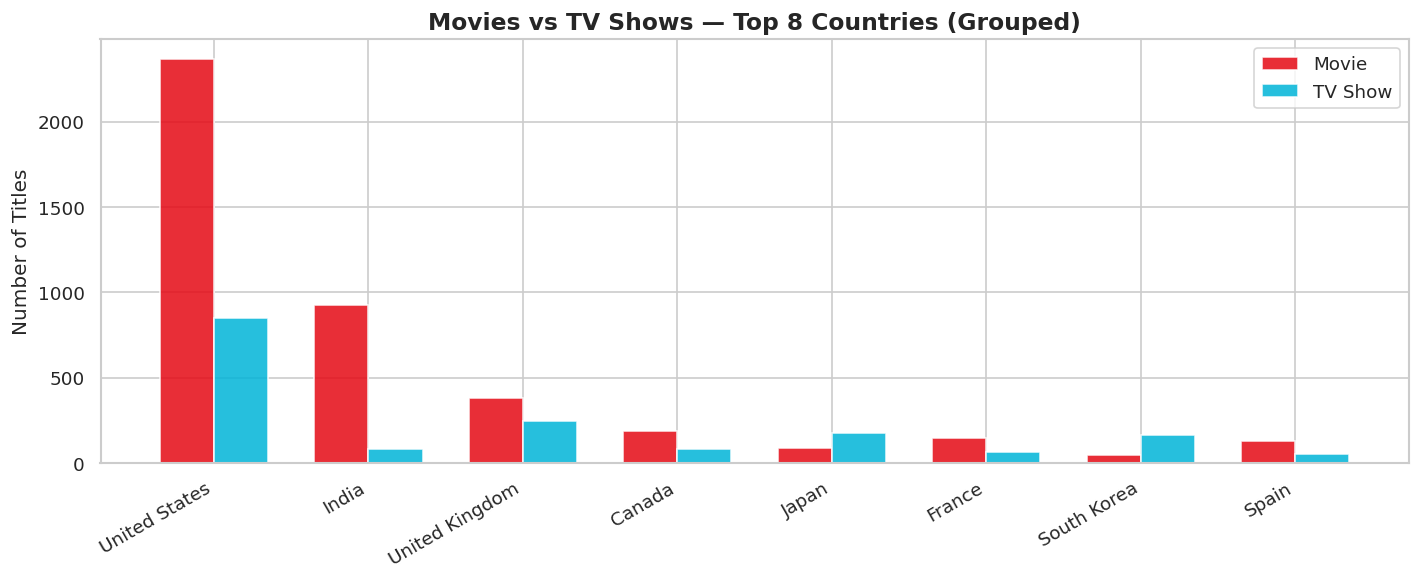

  → saved plot_05_grouped_bar.png


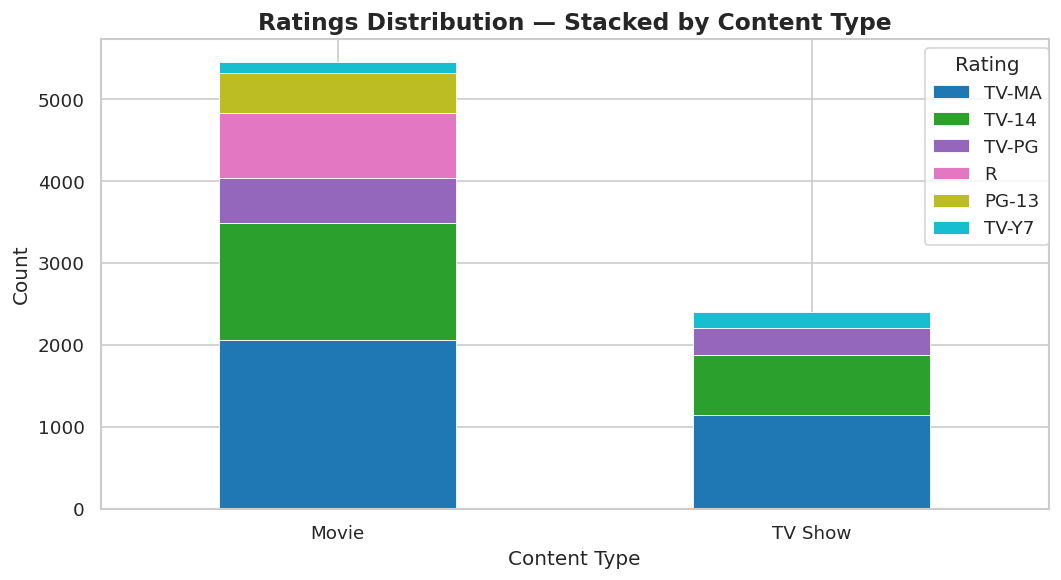

  → saved plot_06_stacked_bar.png


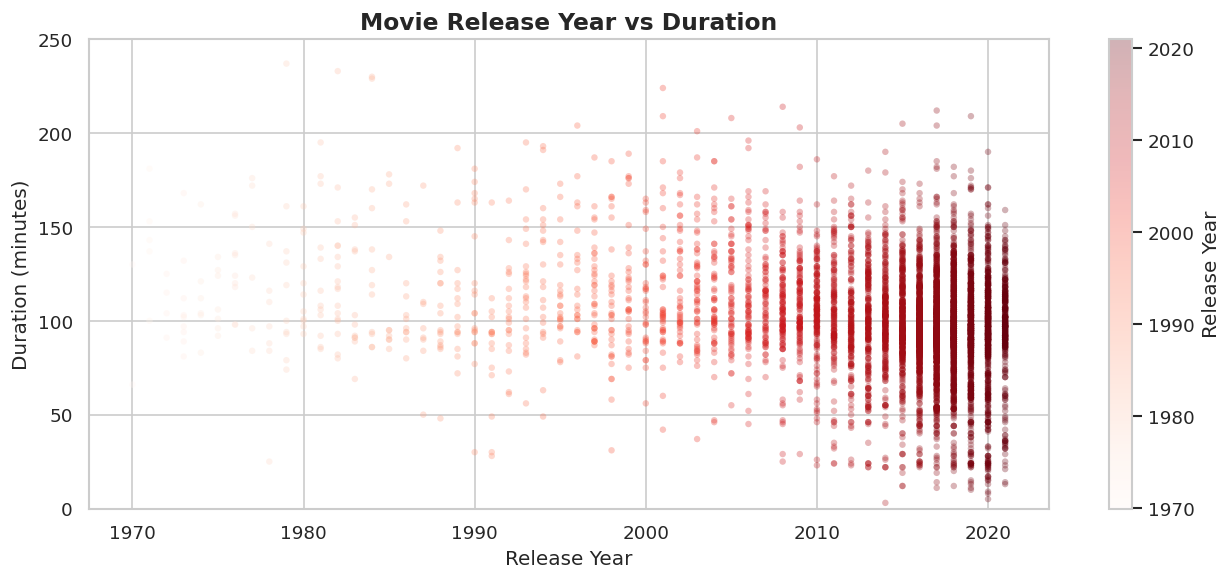

  → saved plot_07_scatter.png
  Year–Duration correlation: -0.233  (near zero — year doesn't predict runtime)


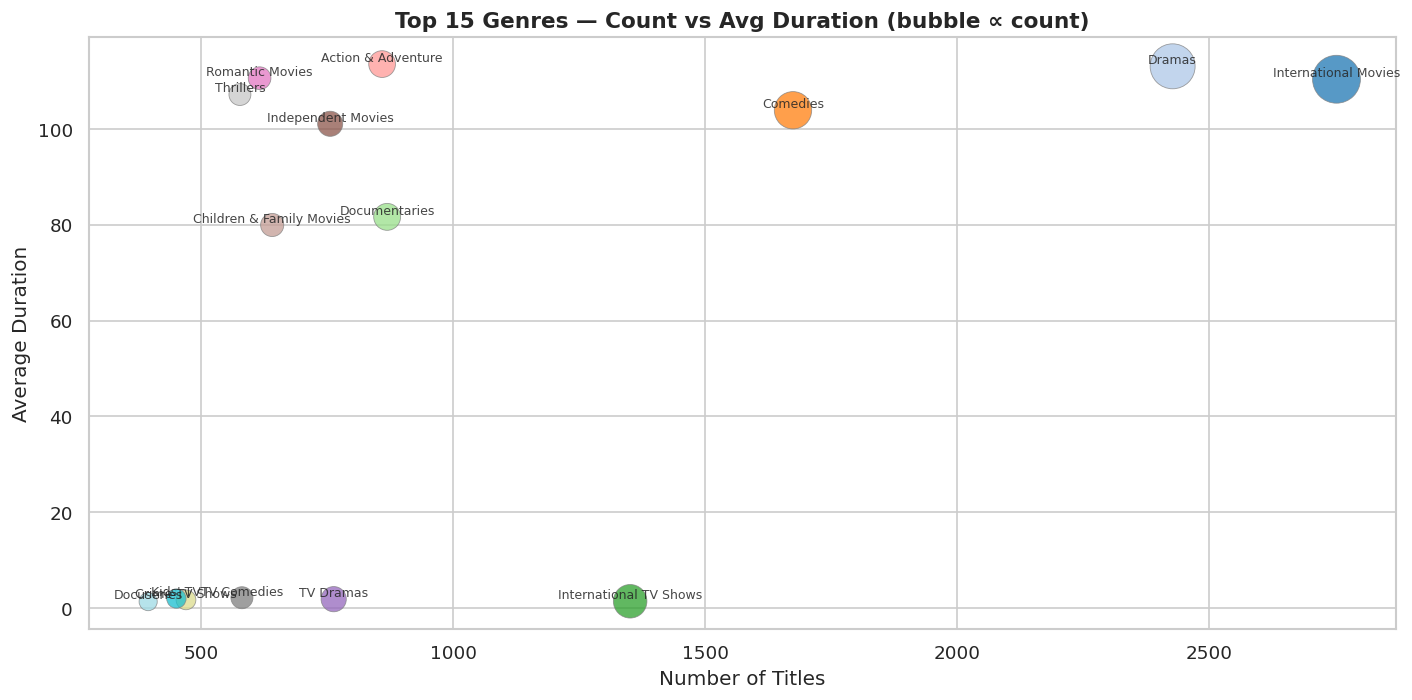

  → saved plot_08_bubble.png


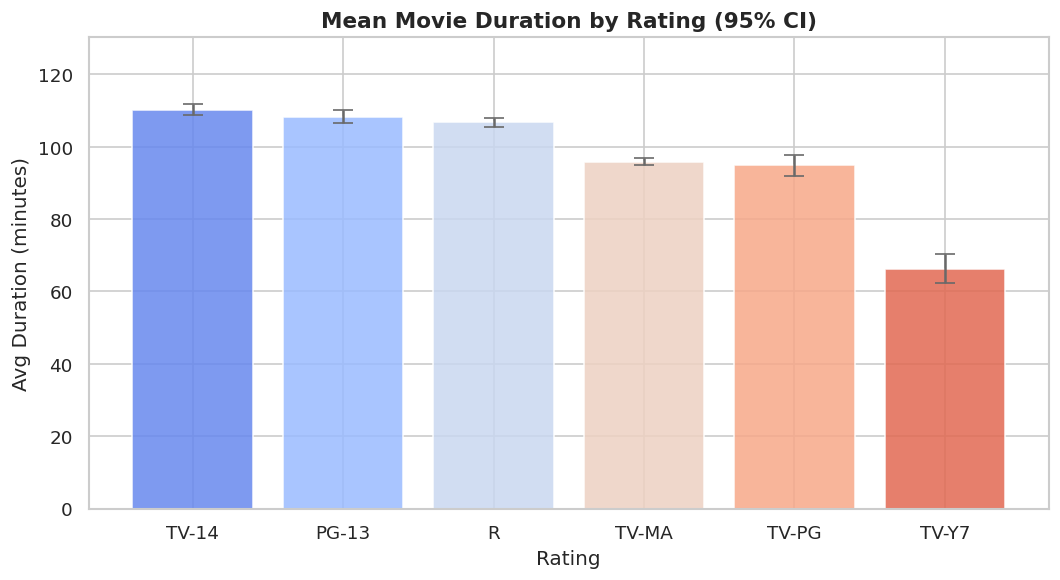

  → saved plot_09_errorbars.png
  → saved plot_10_interactive_line.html  (open in browser)
  → saved plot_11_interactive_bubble.html  (open in browser)


In [22]:
print("\n" + "=" * 60)
print("5. VISUALIZATIONS (matplotlib/seaborn + plotly)")
print("=" * 60)
 
# Helper: save and show
def save_show(name):
    plt.savefig(f"{name}.png", bbox_inches="tight")
    plt.show()
    print(f"  → saved {name}.png")
 
 
# 5.1 Pie chart — Movies vs TV Shows
type_counts = df["type"].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#E50914", "#221F1F"],
    explode=(0.03, 0.03),
    textprops={"color": "white", "fontsize": 13},
)
ax.set_facecolor("#141414")
fig.patch.set_facecolor("#141414")
ax.set_title("Netflix: Movies vs TV Shows", color="white", fontsize=15, pad=15)
plt.tight_layout()
save_show("plot_01_pie")
 
# 5.2 Box plot — Duration by type
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ctype, unit, color in zip(
    axes,
    ["Movie", "TV Show"],
    ["minutes", "seasons"],
    ["#E50914", "#00B4D8"],
):
    subset = df[df["type"] == ctype]["duration_value"].dropna()
    ax.boxplot(
        subset,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.7),
        medianprops=dict(color="white", linewidth=2),
    )
    med = subset.median()
    ax.annotate(f"Median: {med:.0f}", xy=(1, med), xytext=(1.15, med), fontsize=10, color="grey")
    ax.set_title(f"{ctype} Duration ({unit})", fontsize=12)
    ax.set_xticks([])
fig.suptitle("Duration Distribution by Content Type", fontsize=14, fontweight="bold")
plt.tight_layout()
save_show("plot_02_boxplot")
 
# 5.3 Line chart — Content added per year (multi-line)
df["year_added"] = df["date_added"].dt.year
yearly = df.groupby(["year_added", "type"]).size().unstack(fill_value=0)
yearly = yearly[(yearly.index >= 2010) & (yearly.index <= 2021)]
fig, ax = plt.subplots(figsize=(11, 5))
for col, color in zip(yearly.columns, ["#E50914", "#00B4D8"]):
    ax.plot(yearly.index, yearly[col], marker="o", label=col, color=color, linewidth=2.5)
ax.set_title("Content Added to Netflix per Year (2010–2021)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year Added")
ax.set_ylabel("Number of Titles")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(title="Type")
plt.tight_layout()
save_show("plot_03_line")
 
# 5.4 Bar chart — Top 10 Countries
df["primary_country"] = df["country"].str.split(",").str[0].str.strip()
country_counts = (
    df[df["primary_country"] != "Unknown"]["primary_country"].value_counts().head(10)
)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(country_counts.index, country_counts.values,
              color=sns.color_palette("Reds_r", len(country_counts)))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Top 10 Countries by Number of Titles", fontsize=14, fontweight="bold")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Titles")
ax.set_ylim(0, country_counts.max() * 1.12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_show("plot_04_bar")
 
# 5.5 Grouped bar chart — Movies vs TV Shows per top country
top_countries = country_counts.index.tolist()[:8]
grouped = (
    df[df["primary_country"].isin(top_countries)]
    .groupby(["primary_country", "type"])
    .size()
    .unstack(fill_value=0)
    .loc[top_countries]
)
x = np.arange(len(grouped))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, grouped.get("Movie", 0), width, label="Movie", color="#E50914", alpha=0.85)
ax.bar(x + width / 2, grouped.get("TV Show", 0), width, label="TV Show", color="#00B4D8", alpha=0.85)
ax.set_title("Movies vs TV Shows — Top 8 Countries (Grouped)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(grouped.index, rotation=30, ha="right")
ax.set_ylabel("Number of Titles")
ax.legend()
plt.tight_layout()
save_show("plot_05_grouped_bar")
 
# 5.6 Stacked bar chart — Ratings per type
top_ratings = df["rating"].value_counts().head(6).index.tolist()
rating_type = (
    df[df["rating"].isin(top_ratings)]
    .groupby(["type", "rating"])
    .size()
    .unstack(fill_value=0)[top_ratings]
)
ax = rating_type.plot(kind="bar", stacked=True, figsize=(9, 5),
                      colormap="tab10", edgecolor="white", linewidth=0.5)
ax.set_title("Ratings Distribution — Stacked by Content Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Content Type")
ax.set_ylabel("Count")
ax.legend(title="Rating", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
plt.tight_layout()
save_show("plot_06_stacked_bar")
 
# 5.7 Scatter plot — Release Year vs Duration (Movies)
movies = df[(df["type"] == "Movie") & (df["release_year"] >= 1970)].copy()
fig, ax = plt.subplots(figsize=(11, 5))
sc = ax.scatter(
    movies["release_year"], movies["duration_value"],
    alpha=0.3, s=15, c=movies["release_year"], cmap="Reds", edgecolors="none"
)
plt.colorbar(sc, ax=ax, label="Release Year")
ax.set_title("Movie Release Year vs Duration", fontsize=14, fontweight="bold")
ax.set_xlabel("Release Year")
ax.set_ylabel("Duration (minutes)")
ax.set_ylim(0, 250)
plt.tight_layout()
save_show("plot_07_scatter")
corr = movies["release_year"].corr(movies["duration_value"])
print(f"  Year–Duration correlation: {corr:.3f}  (near zero — year doesn't predict runtime)")
 
# 5.8 Bubble chart — Top genres count vs avg duration
genres_exp = df.assign(genre=df["listed_in"].str.split(", ")).explode("genre")
genre_stats = (
    genres_exp.groupby("genre")
    .agg(count=("show_id", "count"), avg_duration=("duration_value", "mean"))
    .reset_index()
    .sort_values("count", ascending=False)
    .head(15)
)
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(
    genre_stats["count"], genre_stats["avg_duration"],
    s=genre_stats["count"] * 0.3,
    c=range(len(genre_stats)), cmap="tab20", alpha=0.75, edgecolors="grey", linewidth=0.5
)
for _, row in genre_stats.iterrows():
    ax.annotate(row["genre"], (row["count"], row["avg_duration"]),
                fontsize=7.5, ha="center", va="bottom", alpha=0.85)
ax.set_title("Top 15 Genres — Count vs Avg Duration (bubble ∝ count)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("Average Duration")
plt.tight_layout()
save_show("plot_08_bubble")
 
# 5.9 Error bar chart — Mean duration per rating (95% CI)
movie_ratings = df[(df["type"] == "Movie") & (df["rating"].isin(top_ratings))].copy()
rating_agg = (
    movie_ratings.groupby("rating")["duration_value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
rating_agg["ci95"] = 1.96 * rating_agg["std"] / np.sqrt(rating_agg["count"])
rating_agg = rating_agg.sort_values("mean", ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    rating_agg["rating"], rating_agg["mean"],
    yerr=rating_agg["ci95"], capsize=6,
    color=sns.color_palette("coolwarm", len(rating_agg)), alpha=0.85,
    edgecolor="white", error_kw=dict(elinewidth=1.5, ecolor="dimgrey")
)
ax.set_title("Mean Movie Duration by Rating (95% CI)", fontsize=13, fontweight="bold")
ax.set_xlabel("Rating")
ax.set_ylabel("Avg Duration (minutes)")
ax.set_ylim(0, rating_agg["mean"].max() + 20)
plt.tight_layout()
save_show("plot_09_errorbars")
 
# 5.10 Interactive Plotly — Content growth by country
top5 = country_counts.head(5).index.tolist()
ct_yearly = (
    df[df["primary_country"].isin(top5)]
    .groupby(["primary_country", "year_added"])
    .size()
    .reset_index(name="count")
)
ct_yearly = ct_yearly[ct_yearly["year_added"].between(2015, 2021)]
fig_px = px.line(
    ct_yearly, x="year_added", y="count", color="primary_country", markers=True,
    title="📈 Yearly Content Additions — Top 5 Countries (Interactive)",
    labels={"year_added": "Year", "count": "Titles Added", "primary_country": "Country"},
    color_discrete_sequence=px.colors.qualitative.Plotly,
    template="plotly_dark",
)
fig_px.update_layout(xaxis=dict(dtick=1), hovermode="x unified")
fig_px.write_html("plot_10_interactive_line.html")
print("  → saved plot_10_interactive_line.html  (open in browser)")
 
# Interactive bubble — Rating vs Avg Duration
rate_dur = (
    df.groupby(["rating", "type"])
    .agg(avg_dur=("duration_value", "mean"), count=("show_id", "count"))
    .reset_index()
)
fig_bub = px.scatter(
    rate_dur, x="rating", y="avg_dur", size="count", color="type",
    hover_name="rating", size_max=60,
    title="🫧 Rating vs Avg Duration — Bubble Size = Number of Titles",
    labels={"avg_dur": "Avg Duration", "rating": "Rating"},
    color_discrete_map={"Movie": "#E50914", "TV Show": "#00B4D8"},
    template="plotly_dark",
)
fig_bub.write_html("plot_11_interactive_bubble.html")
print("  → saved plot_11_interactive_bubble.html  (open in browser)")
 

In [23]:
print("\n" + "=" * 60)
print("6. FEATURE ENGINEERING")
print("=" * 60)
 
# 6.1 Ratio & Math
df["age_when_added"] = df["year_added"] - df["release_year"]   # time-to-platform
df["log_duration"] = np.log1p(df["duration_value"])            # reduce right-skew
 
# 6.2 Binning
df["era"] = pd.cut(
    df["release_year"],
    bins=[1900, 1980, 2000, 2010, 2016, 2025],
    labels=["Classic", "80s-90s", "2000s", "2010s", "Recent"],
)
movie_mask = df["type"] == "Movie"
df.loc[movie_mask, "duration_bucket"] = pd.cut(
    df.loc[movie_mask, "duration_value"],
    bins=[0, 60, 90, 120, 180, 9999],
    labels=["Short", "Standard-", "Standard+", "Long", "Epic"],
)
 
# 6.3 Date/time
df["month_added"] = df["date_added"].dt.month
df["quarter_added"] = df["date_added"].dt.quarter
df["is_q4_release"] = (df["quarter_added"] == 4).astype(int)
print(f"Q4 additions: {df['is_q4_release'].mean()*100:.1f}%  (Netflix pushes holiday content)")
 
# 6.4 Count/aggregation
df["num_genres"] = df["listed_in"].str.count(",") + 1
df["cast_size"] = df["cast"].apply(lambda x: len(str(x).split(",")) if pd.notna(x) and str(x) != "Unknown" else 0)
df["num_countries"] = df["country"].apply(lambda x: len(str(x).split(",")) if pd.notna(x) and str(x) != "Unknown" else 1)
dir_counts = df[df["director"] != "Unknown"]["director"].value_counts()
df["director_title_count"] = df["director"].map(dir_counts).fillna(0)
 
# 6.5 Feature combination
df["is_collab_title"] = ((df["num_countries"] > 1) & (df["num_genres"] > 2)).astype(int)
df["era_enc"] = df["era"].cat.codes
 
print("\nEngineered features summary:")
eng_cols = ["age_when_added", "log_duration", "num_genres", "cast_size",
            "num_countries", "director_title_count", "is_q4_release", "is_collab_title"]
print(df[eng_cols].describe().round(2).to_string())
 


6. FEATURE ENGINEERING
Q4 additions: 25.9%  (Netflix pushes holiday content)

Engineered features summary:
       age_when_added  log_duration  num_genres  cast_size  num_countries  director_title_count  is_q4_release  is_collab_title
count         8797.00       8804.00     8807.00    8807.00        8807.00               8807.00        8807.00          8807.00
mean             4.69          3.46        2.19       7.28           1.23                  1.56           0.26             0.06
std              8.79          1.71        0.78       4.86           0.67                  2.35           0.44             0.23
min             -3.00          0.69        1.00       0.00           1.00                  0.00           0.00             0.00
25%              0.00          1.10        2.00       4.00           1.00                  0.00           0.00             0.00
50%              1.00          4.49        2.00       8.00           1.00                  1.00           0.00             0


7. FEATURE SELECTION — MUTUAL INFORMATION


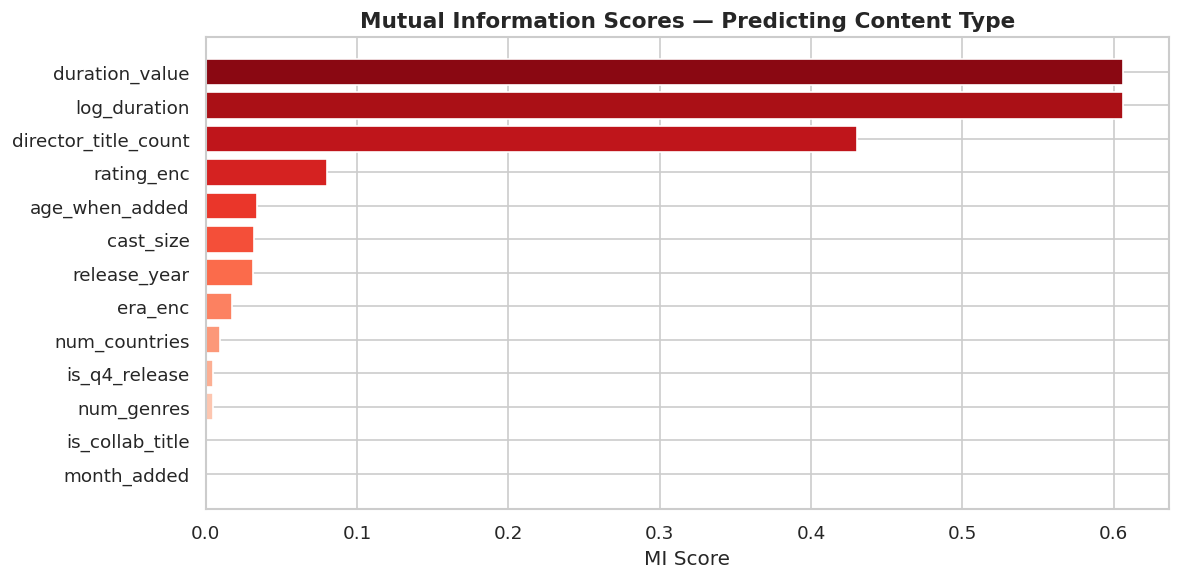

  → saved plot_12_mutual_info.png
Top 5 features by MI score:
duration_value          0.6060
log_duration            0.6060
director_title_count    0.4303
rating_enc              0.0799
age_when_added          0.0342
→ duration features dominate; they cleanly separate Movies from TV Shows


In [24]:
print("\n" + "=" * 60)
print("7. FEATURE SELECTION — MUTUAL INFORMATION")
print("=" * 60)
 
feature_cols = [
    "release_year", "duration_value", "log_duration",
    "rating_enc", "age_when_added", "num_genres",
    "cast_size", "num_countries", "director_title_count",
    "month_added", "is_q4_release", "is_collab_title", "era_enc",
]
X = df[feature_cols].fillna(0)
y = df["type_enc"]
 
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_SEED)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(mi_series.index, mi_series.values,
        color=sns.color_palette("Reds_r", len(mi_series)))
ax.set_title("Mutual Information Scores — Predicting Content Type", fontsize=13, fontweight="bold")
ax.set_xlabel("MI Score")
ax.invert_yaxis()
plt.tight_layout()
save_show("plot_12_mutual_info")
 
print("Top 5 features by MI score:")
print(mi_series.head(5).round(4).to_string())
print("→ duration features dominate; they cleanly separate Movies from TV Shows")
 


8. DIMENSIONALITY REDUCTION — PCA


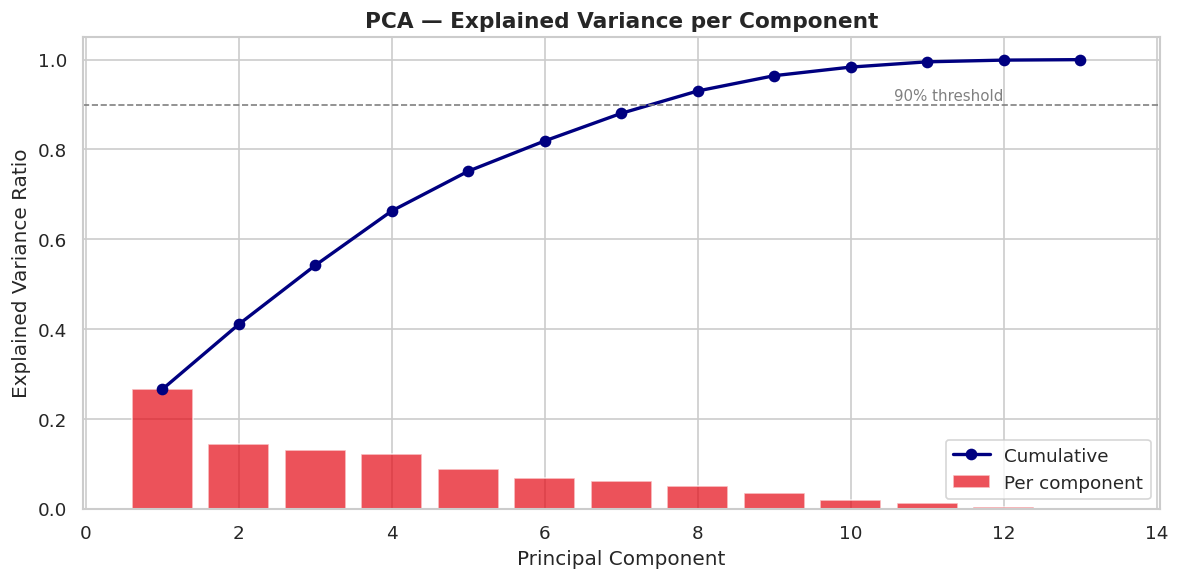

  → saved plot_13_pca_scree.png
Components needed for 90% variance: 8 / 13


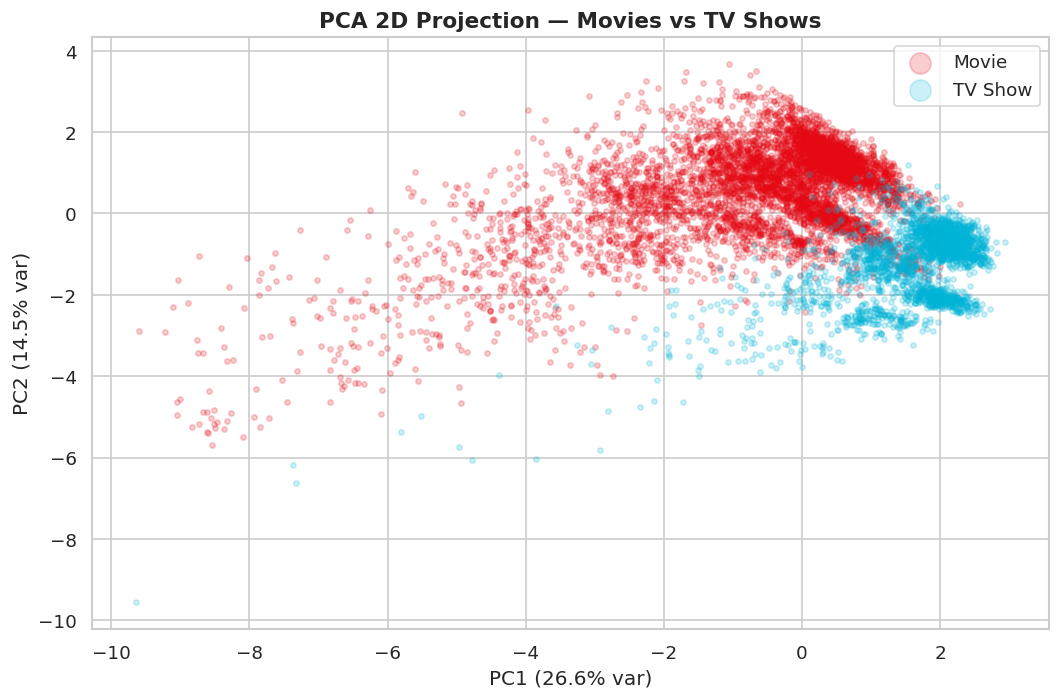

  → saved plot_14_pca_2d.png
→ Classes are partially separable in 2D, mainly along PC1 (driven by duration)


In [25]:
print("\n" + "=" * 60)
print("8. DIMENSIONALITY REDUCTION — PCA")
print("=" * 60)
 
X_scaled = StandardScaler().fit_transform(X)
 
# Scree plot
pca_full = PCA(n_components=len(feature_cols), random_state=RANDOM_SEED)
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained) + 1), explained, alpha=0.7, label="Per component", color="#E50914")
ax.plot(range(1, len(cumulative) + 1), cumulative, marker="o", color="navy",
        linewidth=2, label="Cumulative")
ax.axhline(0.90, linestyle="--", color="grey", linewidth=1)
ax.text(len(explained) - 1, 0.91, "90% threshold", ha="right", color="grey", fontsize=9)
ax.set_title("PCA — Explained Variance per Component", fontsize=13, fontweight="bold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.legend()
plt.tight_layout()
save_show("plot_13_pca_scree")
 
n90 = int(np.argmax(cumulative >= 0.90)) + 1
print(f"Components needed for 90% variance: {n90} / {len(feature_cols)}")
 
# 2D projection
pca2 = PCA(n_components=2, random_state=RANDOM_SEED)
X_2d = pca2.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(9, 6))
for val, label, color in [(0, "Movie", "#E50914"), (1, "TV Show", "#00B4D8")]:
    mask = y == val
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.2, s=10, label=label, color=color)
ax.set_title("PCA 2D Projection — Movies vs TV Shows", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend(markerscale=4)
plt.tight_layout()
save_show("plot_14_pca_2d")
print("→ Classes are partially separable in 2D, mainly along PC1 (driven by duration)")
 

Hope you doing well!